In [1]:
import glob
import json
import os
import re

import numpy as np
import xarray as xr
import pandas as pd
import cftime

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams["figure.figsize"] = (11, 9)

In [2]:
# constants 
DC8_RE = re.compile(r"asiaaq_(\d{8})_dc8_.*\.nc4$")
TROP_RE = re.compile(r"asiaaq_(\d{8})_tropomi_l2_([a-z0-9]+)_.*\.nc4$")

CLIP = {
    "no2": (-2e15, 5e16),
    "hcho": (-2e16, 5e16),
    "co": (0.0, 1e19),
}

In [3]:
# Edit these

pairdir = "/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/louisa_asiaaq_cs/asiaaq_cs_06082026/output/pair"
outdir = "./output"

window_hours = 2.0

# "obs" or "model"
field = "obs"

# plot all overpasses regardless of coincidence
all_overpasses = False

# None or list like ["20180502","20180504"]
dates = None

os.makedirs(outdir, exist_ok=True)

In [16]:
def _dict_json(ds):
    """Return the parsed MELODIES-MONET dict_json global attr, or {}."""
    raw = ds.attrs.get("dict_json")
    if not raw:
        return {}
    try:
        return json.loads(raw)
    except (ValueError, TypeError):
        return {}


def _obs_var(ds):
    """Name of the observation data variable in a TROPOMI pair file."""
    meta = _dict_json(ds)
    obs_vars = meta.get("obs_vars") or []
    model_vars = set(meta.get("model_vars") or [])
    for v in obs_vars:
        if v in ds.data_vars:
            return v
    # fallback: a (time, n_face) var that is not a declared model var
    for v in ds.data_vars:
        if v not in model_vars and set(ds[v].dims) >= {"time", "n_face"}:
            return v
    raise KeyError(f"could not find an obs column variable in {list(ds.data_vars)}")


def _wrap180(lon):
    """Normalize longitudes to [-180, 180) so both files share a convention."""
    return (np.asarray(lon, dtype=float) + 180.0) % 360.0 - 180.0


def _squeeze_track(ds):
    """Pull lon/lat/alt/time 1-D arrays out of a DC8 pair (time, x=1)."""
    d = ds.squeeze(drop=False)
    lon = _wrap180(np.asarray(d["longitude"].values, float).ravel())
    lat = np.asarray(d["latitude"].values, float).ravel()
    alt = (np.asarray(d["altitude"].values, float).ravel()
           if "altitude" in d else np.full_like(lat, np.nan))
    t = np.asarray(d["time"].values)  # datetime64 after CF decode
    return lon, lat, alt, t


# main functions we need
def find_pairs(pairdir):
    """{date: {'dc8': path, 'tropomi': {species: path}}} for dates having both."""
    dc8 = {}
    trop = {}
    for p in sorted(glob.glob(os.path.join(pairdir, "asiaaq_*.nc4"))):
        base = os.path.basename(p)
        m = DC8_RE.match(base)
        if m:
            dc8[m.group(1)] = p
            continue
        m = TROP_RE.match(base)
        if m:
            trop.setdefault(m.group(1), {})[m.group(2)] = p
    out = {}
    for date in sorted(set(dc8) & set(trop)):
        out[date] = {"dc8": dc8[date], "tropomi": trop[date]}
    return out


def coincident_overpasses(flight_t, overpass_t, window_hours):
    """For each overpass, the DC8 sample mask within +/-window and the min dt.

    Returns list of dicts (one per overpass) sorted by ascending min dt.
    """
    win = np.timedelta64(int(window_hours * 3600), "s")
    rows = []
    for k, ot in enumerate(overpass_t):
        dt = np.abs(flight_t - ot)  # timedelta64 array
        in_win = dt <= win
        finite = np.isfinite(flight_t.astype("float64"))
        n_in = int(np.count_nonzero(in_win & finite))
        min_dt = dt[finite].min() if finite.any() else np.timedelta64(10**9, "s")
        rows.append({
            "k": k,
            "overpass_time": ot,
            "mask_in_window": in_win,
            "n_in_window": n_in,
            "min_dt_min": float(min_dt / np.timedelta64(1, "m")),
        })
    rows.sort(key=lambda r: r["min_dt_min"])
    return rows

def _nn_fill(lon_pts, lat_pts, vals, extent, nx=320, ny=320, max_deg=0.6):
    """Nearest-neighbor fill of sparse mesh-cell centers onto a regular grid.

    Returns (xg, yg, G) with G NaN farther than ``max_deg`` from any finite
    cell, so the fill stays honest to actual coverage instead of extrapolating
    across the whole box. Points are pre-filtered to the (padded) extent to
    keep the neighbor search small.
    """
    xg = np.linspace(extent[0], extent[1], nx)
    yg = np.linspace(extent[2], extent[3], ny)
    ok = (np.isfinite(vals) & np.isfinite(lon_pts) & np.isfinite(lat_pts)
          & (lon_pts >= extent[0] - max_deg) & (lon_pts <= extent[1] + max_deg)
          & (lat_pts >= extent[2] - max_deg) & (lat_pts <= extent[3] + max_deg))
    lp, ap, vp = lon_pts[ok], lat_pts[ok], vals[ok]
    if lp.size == 0:
        return xg, yg, np.full((ny, nx), np.nan)
    Xg, Yg = np.meshgrid(xg, yg)
    d2 = (Xg[..., None] - lp) ** 2 + (Yg[..., None] - ap) ** 2
    j = np.argmin(d2, axis=-1)
    dmin = np.sqrt(d2.min(axis=-1))
    G = vp[j].astype(float)
    G[dmin > max_deg] = np.nan
    return xg, yg, G

# TROPOMI species to the in-situ aircraft variable that measures it
DC8_SPECIES = {"no2": "NO2", "co": "CO"}   # DC8 has no HCHO in these files

def _dc8_obs_values(ds):
    """{aircraft_var: (values_1d, units)} for the in-situ obs vars in a DC8 pair."""
    obs_vars = _dict_json(ds).get("obs_vars") or []
    d = ds.squeeze(drop=False)
    out = {}
    for v in obs_vars:
        if v in d:
            out[v] = (np.asarray(d[v].values, float).ravel(),
                      d[v].attrs.get("units", ""))
    return out

def render(date, species, obs, lon_f, lat_f, alt_f, t_f, ov, extent,
           vmin, vmax, units, outpath, field_label,
           air_vals=None, air_units=""):
    """One overlay figure: TROPOMI column point-map + DC8 track."""

    plt.rcParams.update({
        "font.size": 18,
        "axes.titlesize": 24,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16
    })
    
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(14, 9))
    ax = fig.add_subplot(1, 1, 1, projection=proj)

    ax.coastlines(linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor="gray")
    gl = ax.gridlines(draw_labels=True, lw=0.4, color="gray", alpha=0.4, ls=":")
    gl.top_labels = False
    gl.right_labels = False

    #  Background colors 
    ax.add_feature(
        cfeature.OCEAN,
        facecolor="#cfe8f3",   # light blue ocean
        zorder=0
    )
    
    ax.add_feature(
        cfeature.LAND,
        facecolor="#e6d2a8",   # tan/sandy land
        edgecolor="none",
        zorder=0
    )

    ax.set_extent(extent, crs=proj)

    # # --- TROPOMI column background (regridded mesh faces where finite) -------
    # lon_s, lat_s, val_s = obs
    # xg, yg, Gg = _nn_fill(lon_s, lat_s, val_s, extent)
    # sc = ax.pcolormesh(xg, yg, np.ma.masked_invalid(Gg), cmap="Spectral_r",
    #                    vmin=vmin, vmax=vmax, shading="nearest",
    #                    transform=proj, zorder=1, rasterized=True)
    # cb = fig.colorbar(sc, ax=ax, shrink=0.75, aspect=28, pad=0.02, extend="both")
    # cb.set_label(f"TROPOMI {species.upper()} {field_label}  [{units}]",
    #              fontweight="bold")

    # --- DC8 flight track (plain path + markers) -----------------------------
    ok = np.isfinite(lon_f) & np.isfinite(lat_f)
    ax.plot(lon_f[ok], lat_f[ok], "-", color="black", lw=3,
            transform=proj, zorder=3, label="DC8 flight track")
    
    # airborne within the overpass window -> "under the overpass"
    win_ok = ok & ov["mask_in_window"]
    if win_ok.any():
        if air_vals is not None and np.isfinite(air_vals[win_ok]).any():
            fa = air_vals[win_ok][np.isfinite(air_vals[win_ok])]
            avmin, avmax = np.percentile(fa, [2, 98])
            sca = ax.scatter(lon_f[win_ok], lat_f[win_ok], c=air_vals[win_ok],
                             s=90, cmap="plasma", vmin=avmin, vmax=avmax,
                             edgecolors="white", linewidths=1.2, transform=proj,
                             zorder=4,
                             label=f"DC8 {species.upper()} ({win_ok.sum()} pts)")
            cba = fig.colorbar(sca, ax=ax, location="left", shrink=0.6,
                               aspect=22, pad=0.09, extend="both")
            cba.set_label(f"DC8 in-situ {species.upper()}  [{air_units}]",
                          fontweight="bold")
        else:
            ax.scatter(lon_f[win_ok], lat_f[win_ok], s=22, facecolors="none",
                       edgecolors="black", linewidths=0.9, transform=proj,
                       zorder=4, label=f"DC8 within ±window ({win_ok.sum()} pts)")

    idx = np.where(ok)[0]
    if idx.size:
        ax.scatter(lon_f[idx[0]], lat_f[idx[0]], s=180, marker="o", linewidth = 1.5,
                   color="lime", edgecolors="black", zorder=5, label="takeoff")
        ax.scatter(lon_f[idx[-1]], lat_f[idx[-1]], s=180, marker="X", linewidth = 1.5,
                   color="red", edgecolors="black", zorder=5, label="landing")

    ax.legend(loc="lower right", fontsize=18, framealpha=0.9)
    ot = np.datetime_as_string(ov["overpass_time"], unit="m")
    ax.set_title(
        f"ASIA-AQ {date}  |  TROPOMI {species.upper()} overpass {ov['k']} @ {ot}Z\n"
        f"DC8 nearest approach {ov['min_dt_min']:.0f} min, "
        f"{ov['n_in_window']} samples in window", fontweight="bold")

    fig.savefig(outpath, dpi=350, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def process_date(date, entry,):
    print(f"\n=== {date} ===", flush=True)
    with xr.open_dataset(entry["dc8"]) as dc8:
        lon_f, lat_f, alt_f, t_f = _squeeze_track(dc8)
        dc8_obs = _dc8_obs_values(dc8)
    fin = np.isfinite(lon_f) & np.isfinite(lat_f)
    if not fin.any():
        print("  DC8: no finite lon/lat, skipping date.", flush=True)
        return 0
    # flight bounding box (padded) -> map extent
    padx = max((np.nanmax(lon_f[fin]) - np.nanmin(lon_f[fin])) * 0.12, 0.3)
    pady = max((np.nanmax(lat_f[fin]) - np.nanmin(lat_f[fin])) * 0.12, 0.3)
    extent = [np.nanmin(lon_f[fin]) - padx, np.nanmax(lon_f[fin]) + padx,
              np.nanmin(lat_f[fin]) - pady, np.nanmax(lat_f[fin]) + pady]

    n_made = 0
    for species, path in sorted(entry["tropomi"].items()):
        with xr.open_dataset(path) as ds:
            ovar = _obs_var(ds)
        
            if field == "obs":
                plot_var = ovar
            else:
                plot_var = _dict_json(ds).get("model_vars", [ovar])[0]
        
            lon_s = _wrap180(ds["longitude"].values)
            lat_s = np.asarray(ds["latitude"].values, float)
            over_t = np.asarray(ds["time"].values)
            val_all = np.asarray(ds[plot_var].values, float)
            units = ds[ovar].attrs.get("units", "")

        # sanity clip
        lo, hi = CLIP.get(species, (-np.inf, np.inf))
        val_all = np.where((val_all > lo) & (val_all < hi), val_all, np.nan)

        # shared color scale across this species' overpasses (2-98 pct)
        finite_vals = val_all[np.isfinite(val_all)]
        if finite_vals.size == 0:
            print(f"  {species}: no finite obs pixels, skipping.", flush=True)
            continue
        vmin, vmax = np.percentile(finite_vals, [2, 98])

        rows = coincident_overpasses(t_f, over_t, window_hours)
        drew_any = False
        for ov in rows:
            coincident = ov["min_dt_min"] <= window_hours * 60.0
            if not coincident and not all_overpasses:
                continue
            obs_slice = (lon_s, lat_s, val_all[ov["k"]])
            if not np.isfinite(obs_slice[2]).any():
                continue
            outpath = os.path.join(
                outdir,
                f"asiaaq_{date}_tropomi_{species}_dc8_overlay_ov{ov['k']}.png")
            
            dc8_name = DC8_SPECIES.get(species)
            air_vals, air_units = (dc8_obs.get(dc8_name, (None, "")) if dc8_name
                                   else (None, ""))

            render(date, species, obs_slice, lon_f, lat_f, alt_f, t_f, ov,
                   extent, vmin, vmax, units, outpath, field,
                   air_vals=air_vals, air_units=air_units)
            print(f"  {species} ov{ov['k']} "
                  f"({np.datetime_as_string(ov['overpass_time'], unit='m')}Z): "
                  f"dt={ov['min_dt_min']:.0f}min n_in={ov['n_in_window']} "
                  f"-> {os.path.basename(outpath)}", flush=True)
            n_made += 1
            drew_any = True
        if not drew_any:
            best = rows[0]
            print(f"  {species}: no overpass within ±{window_hours}h "
                  f"(closest {best['min_dt_min']:.0f} min). "
                  f"Use --all-overpasses to force.", flush=True)
    return n_made


In [5]:
pairs = find_pairs(pairdir)

if dates is not None:
    pairs = {d: v for d, v in pairs.items() if d in dates}

print("Dates found:")
list(pairs.keys())

Dates found:


['20240202', '20240206', '20240207', '20240211', '20240215']

In [6]:
# total = 0

# for date, entry in pairs.items():
#     total += process_date(date, entry,)

# print(f"\nDone. {total} figure(s) written to {outdir}")


=== 20240211 ===


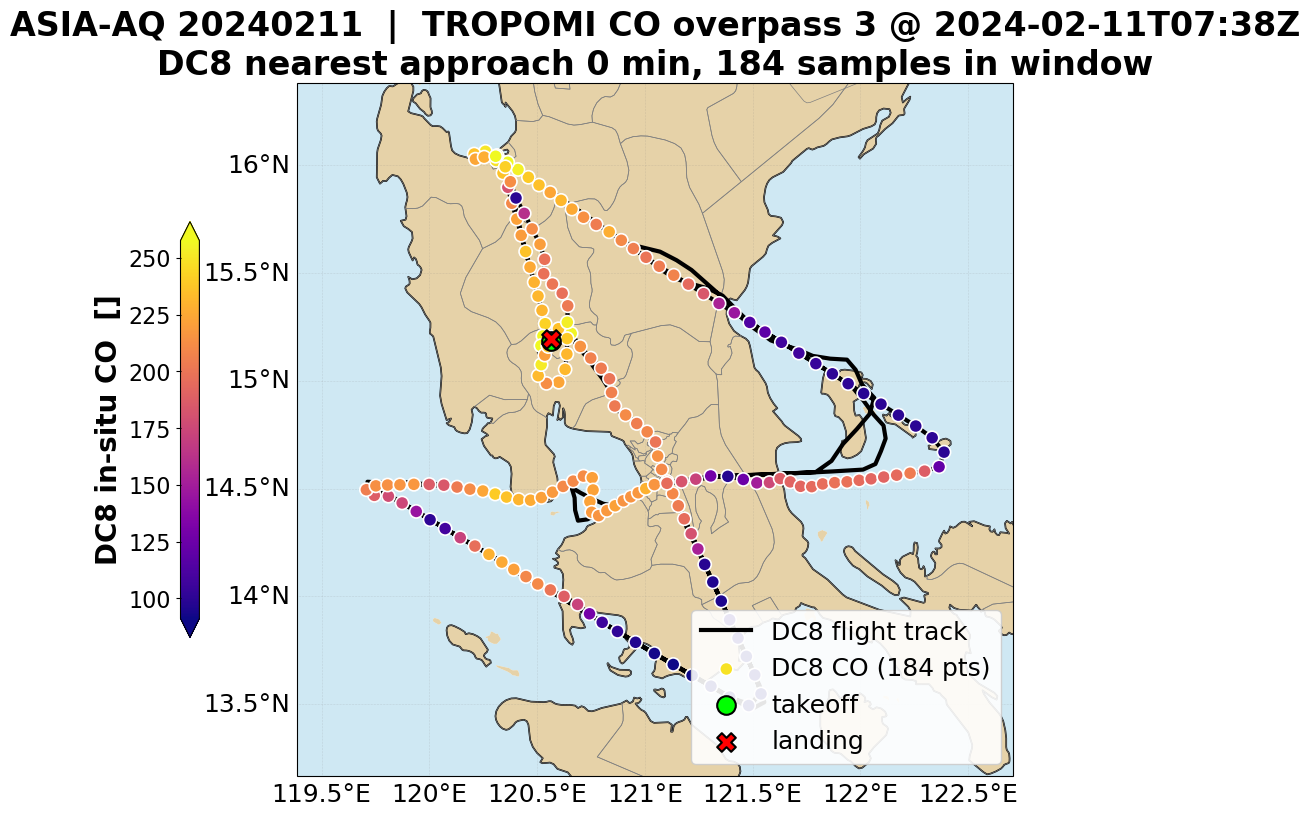

  co ov3 (2024-02-11T07:38Z): dt=0min n_in=184 -> asiaaq_20240211_tropomi_co_dc8_overlay_ov3.png


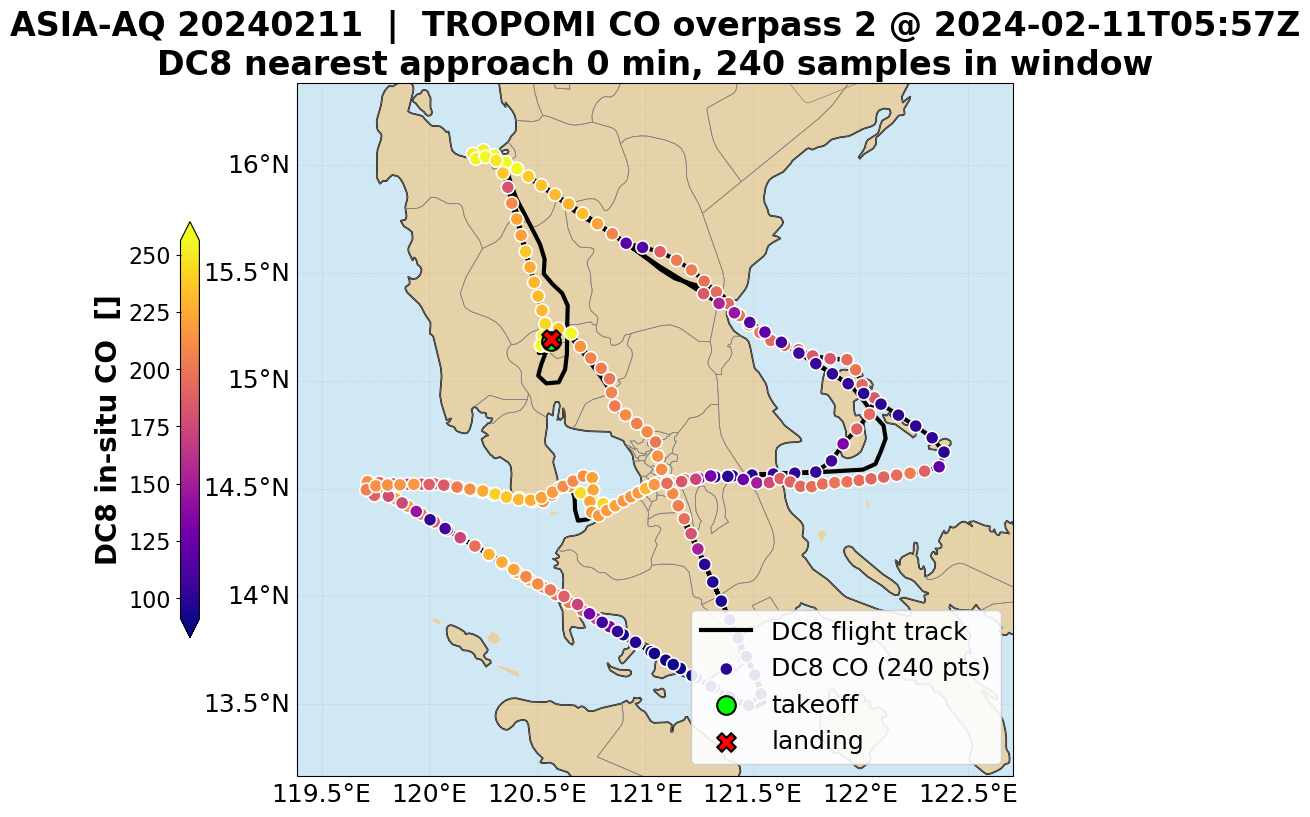

  co ov2 (2024-02-11T05:57Z): dt=0min n_in=240 -> asiaaq_20240211_tropomi_co_dc8_overlay_ov2.png


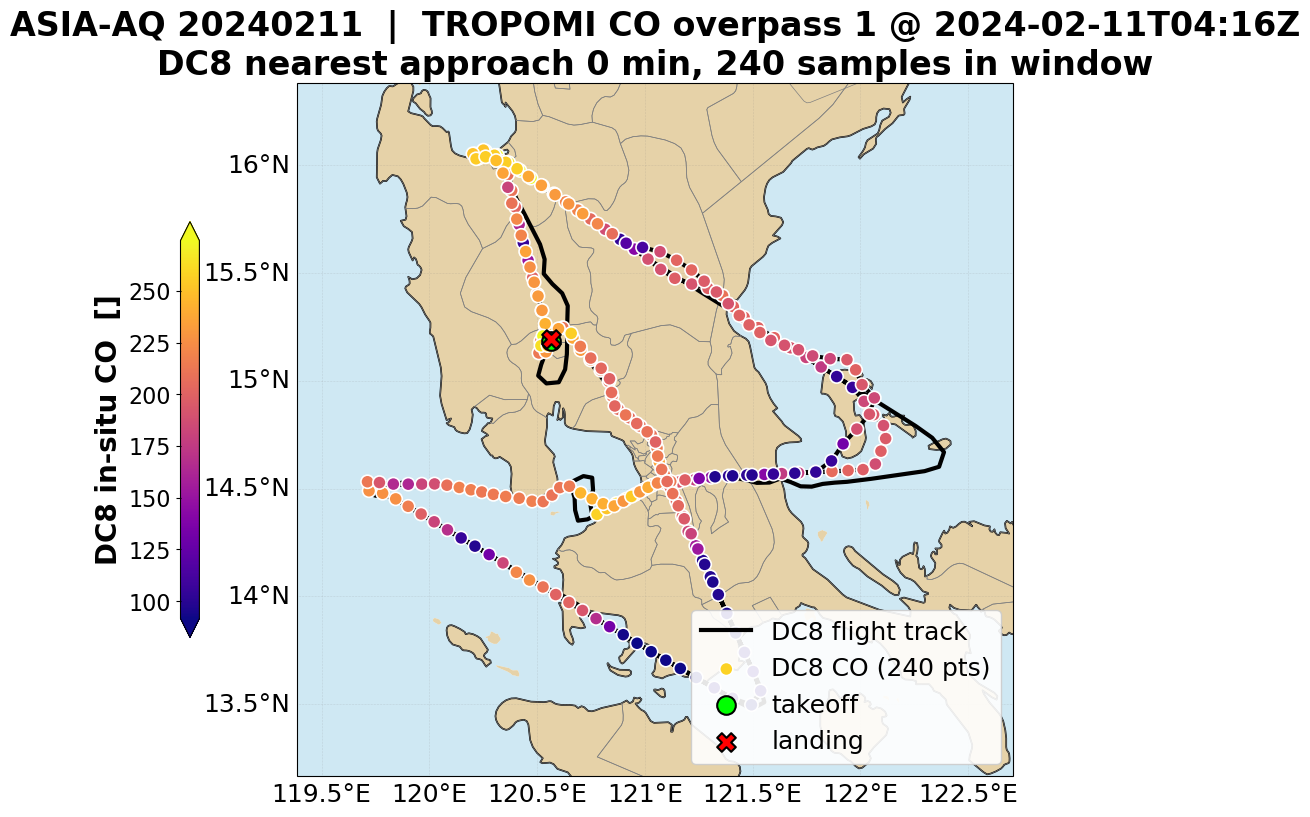

  co ov1 (2024-02-11T04:16Z): dt=0min n_in=240 -> asiaaq_20240211_tropomi_co_dc8_overlay_ov1.png


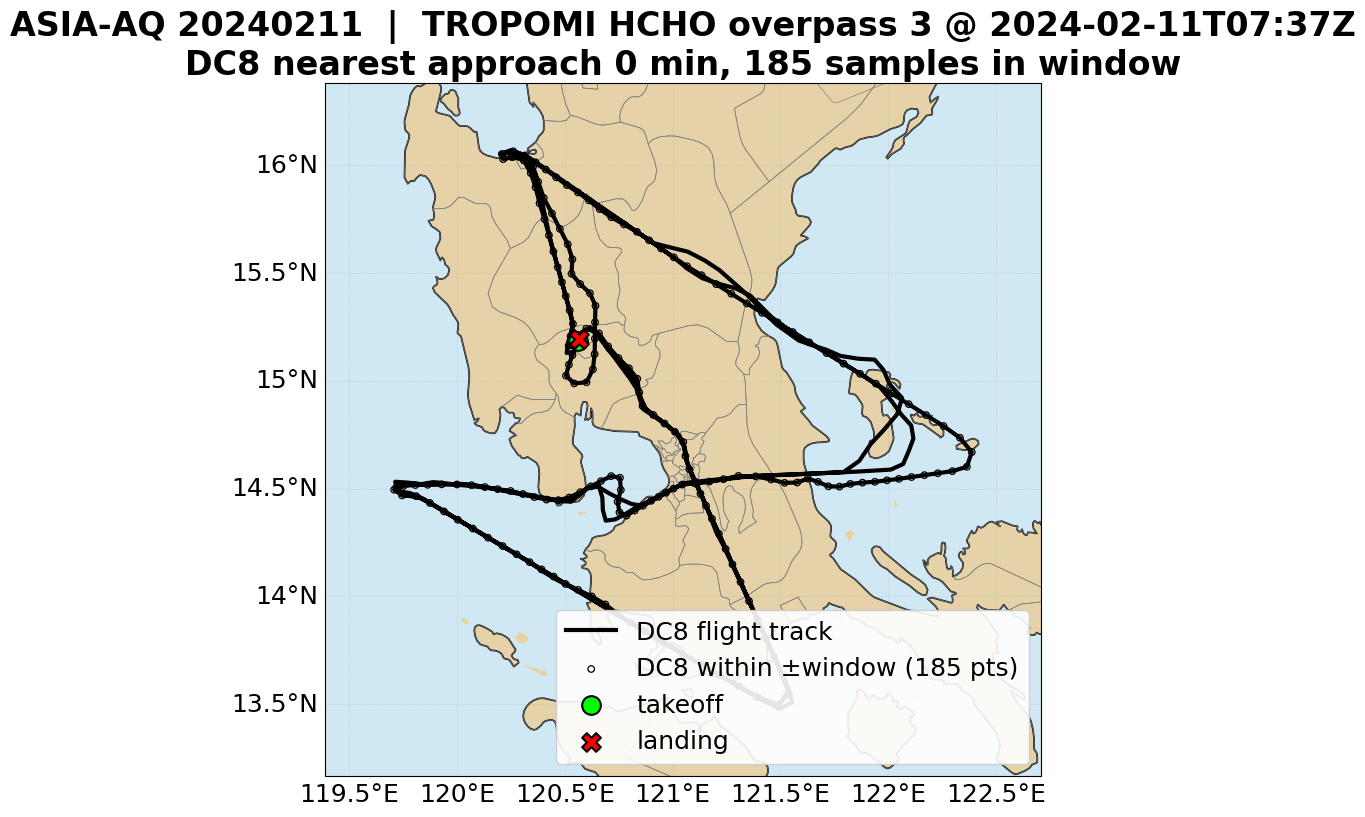

  hcho ov3 (2024-02-11T07:37Z): dt=0min n_in=185 -> asiaaq_20240211_tropomi_hcho_dc8_overlay_ov3.png


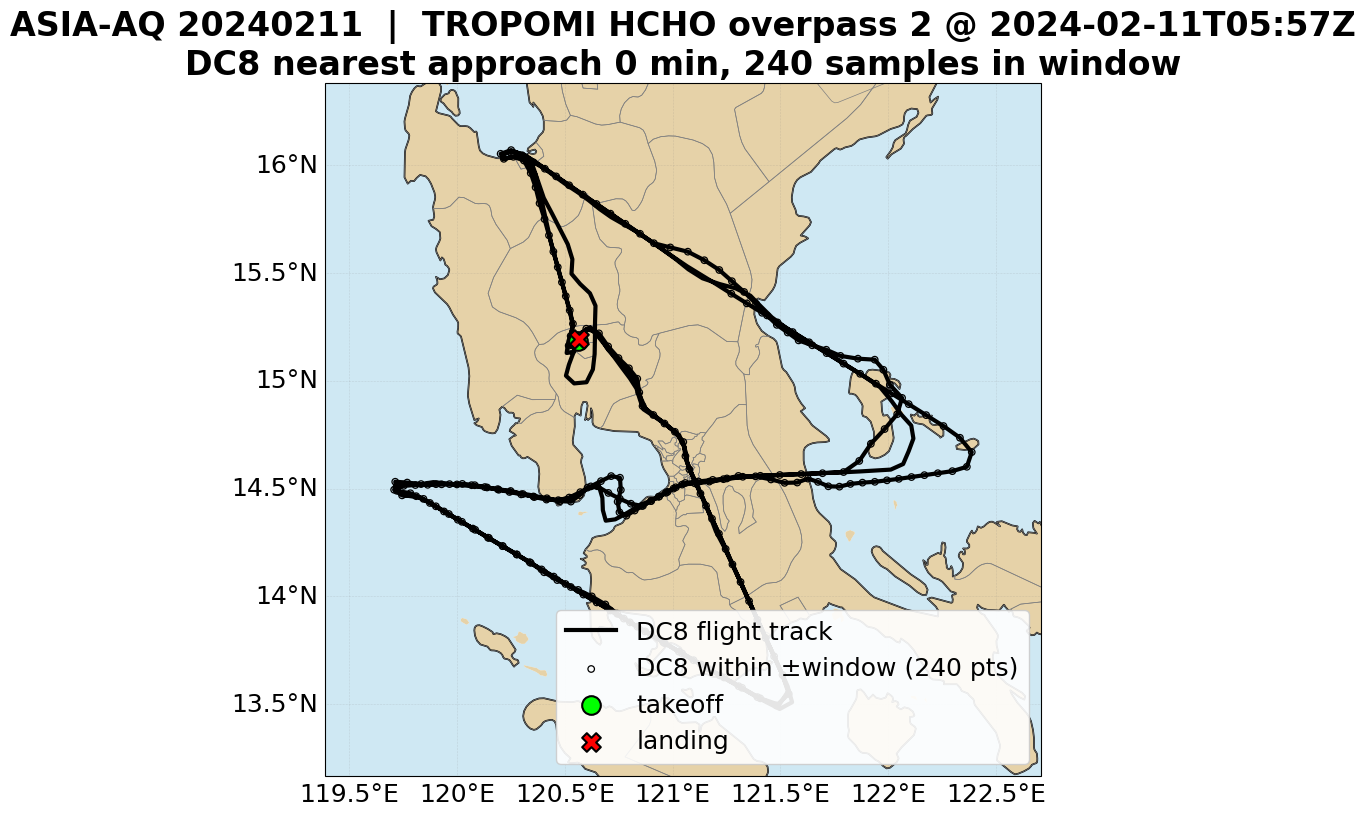

  hcho ov2 (2024-02-11T05:57Z): dt=0min n_in=240 -> asiaaq_20240211_tropomi_hcho_dc8_overlay_ov2.png


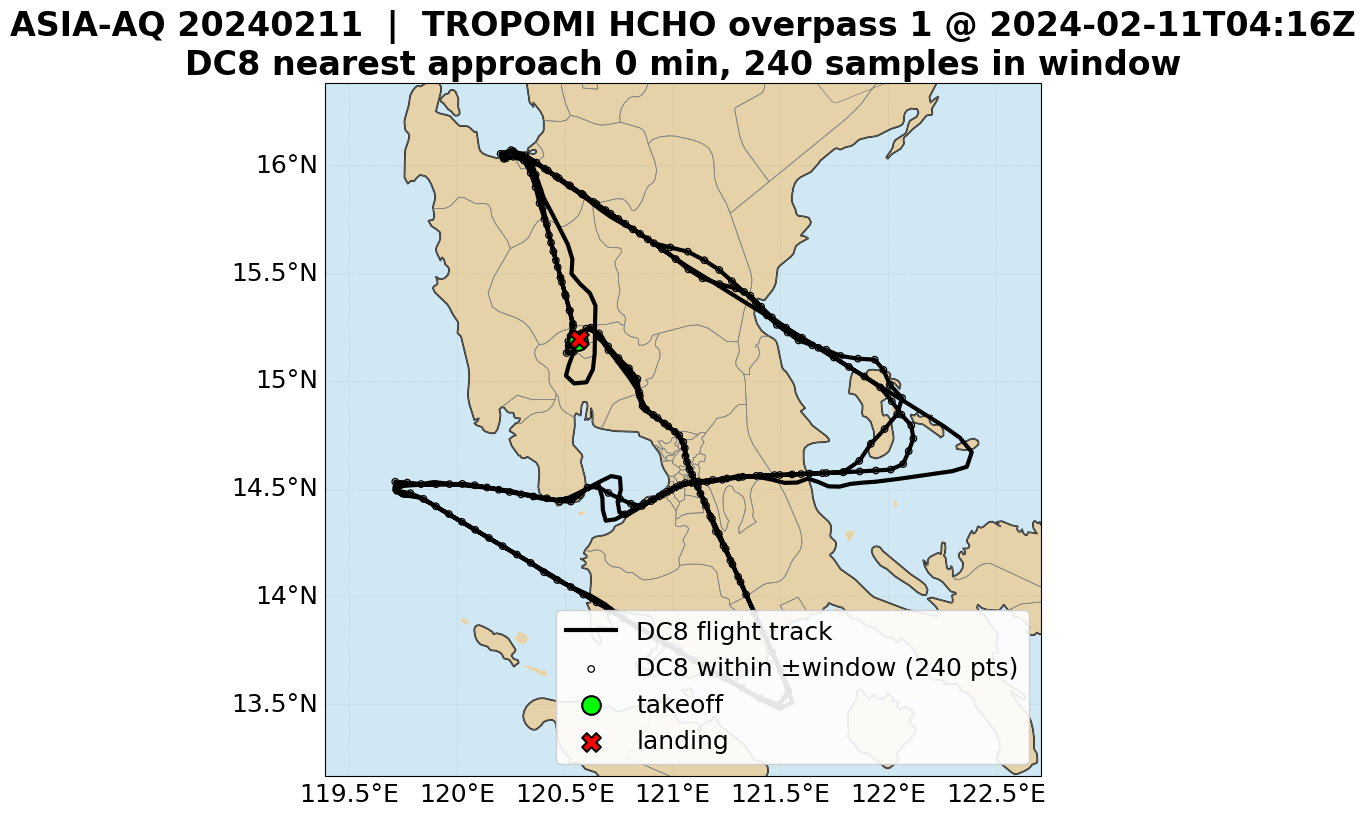

  hcho ov1 (2024-02-11T04:16Z): dt=0min n_in=240 -> asiaaq_20240211_tropomi_hcho_dc8_overlay_ov1.png


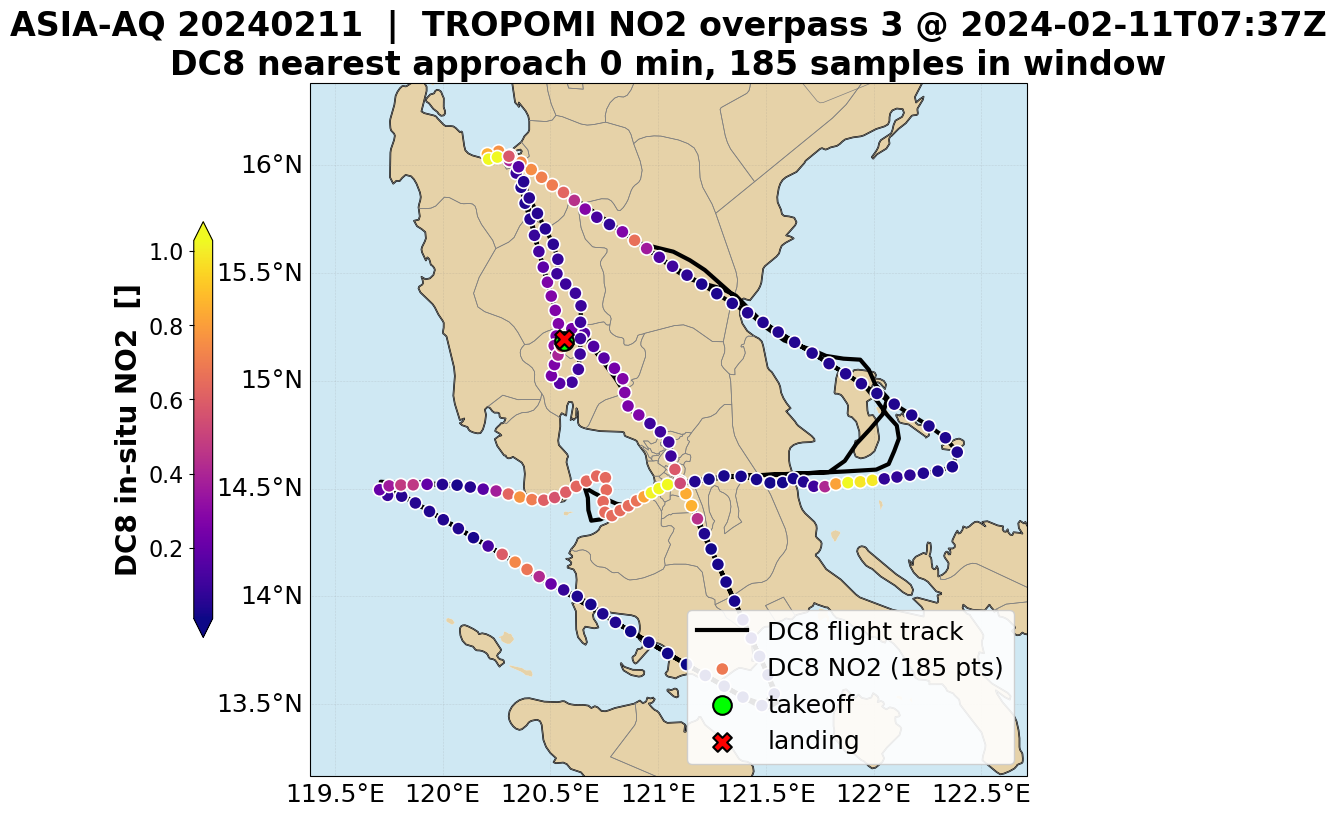

  no2 ov3 (2024-02-11T07:37Z): dt=0min n_in=185 -> asiaaq_20240211_tropomi_no2_dc8_overlay_ov3.png


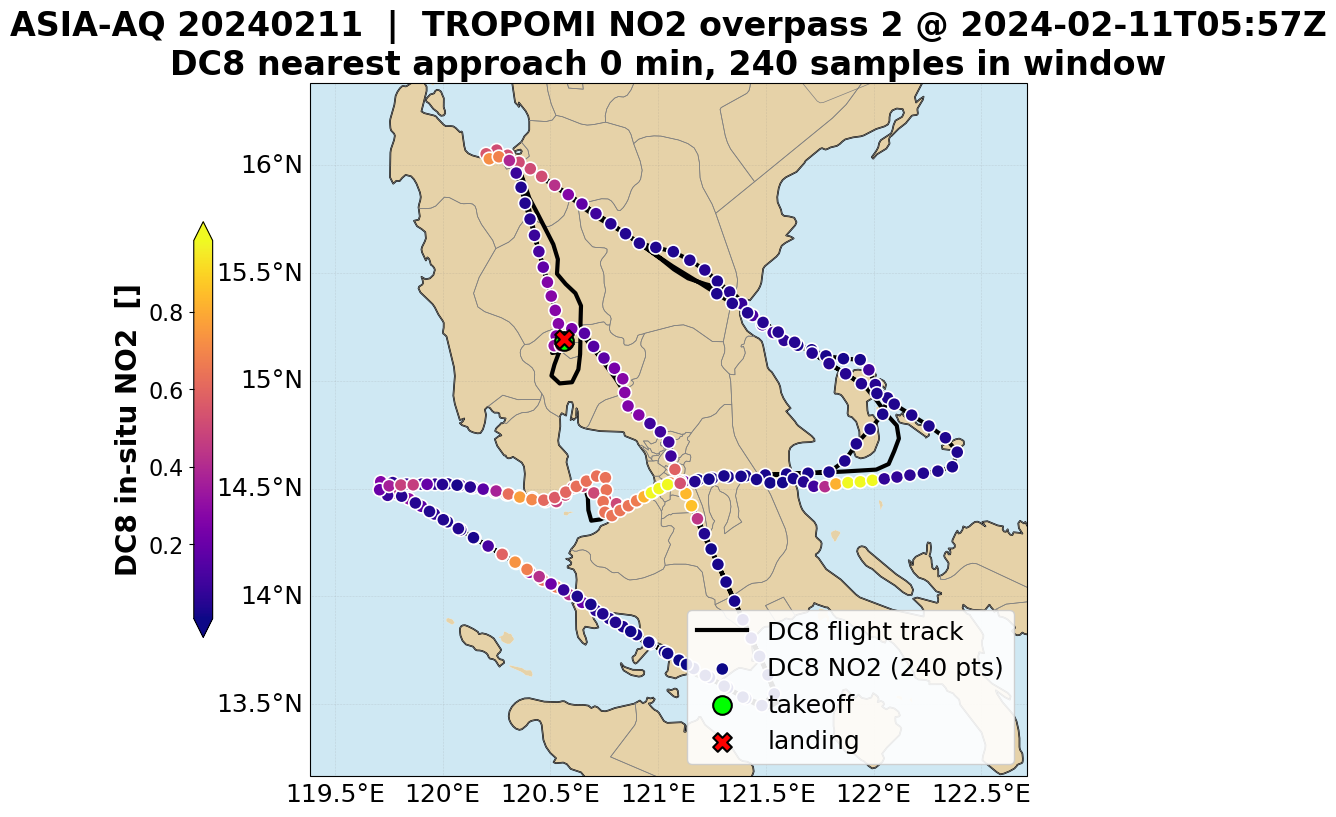

  no2 ov2 (2024-02-11T05:57Z): dt=0min n_in=240 -> asiaaq_20240211_tropomi_no2_dc8_overlay_ov2.png


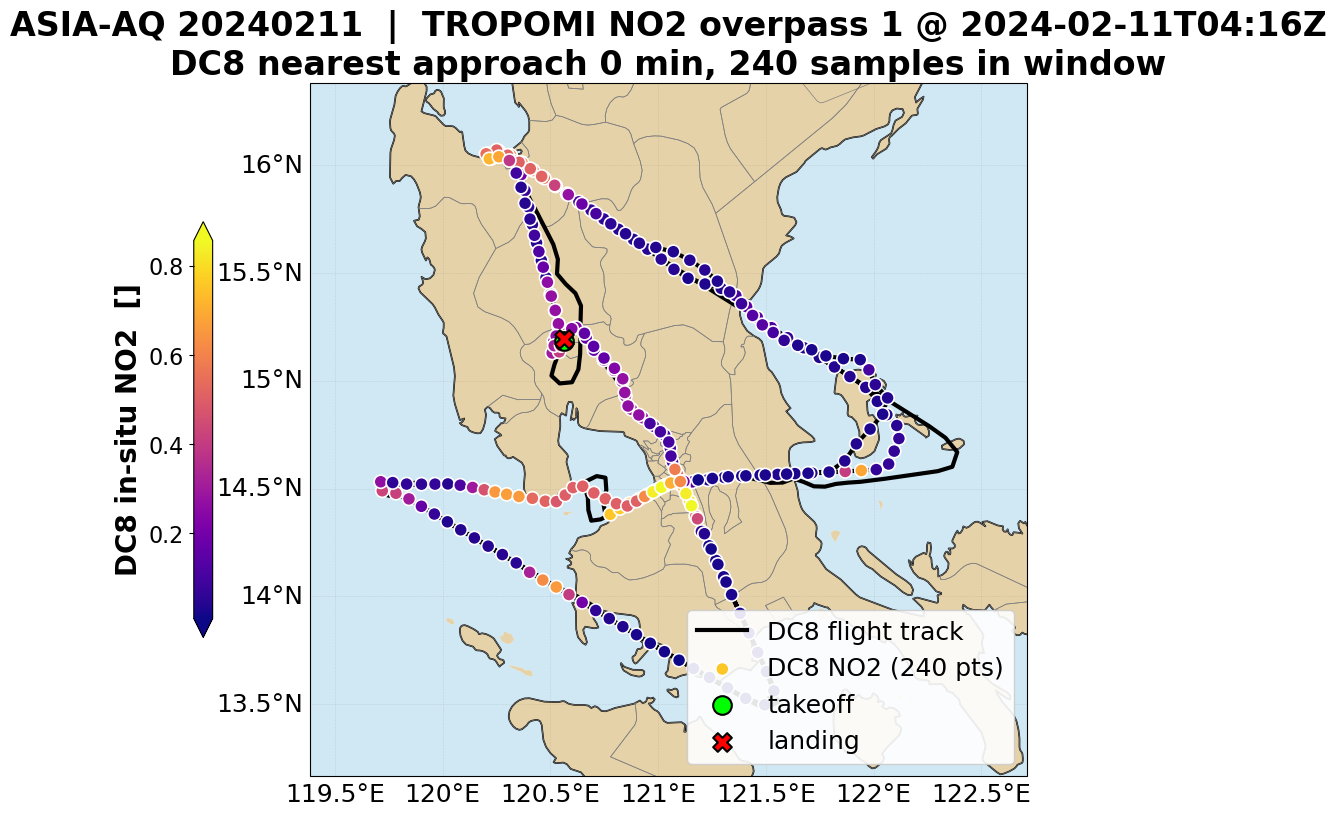

  no2 ov1 (2024-02-11T04:16Z): dt=0min n_in=240 -> asiaaq_20240211_tropomi_no2_dc8_overlay_ov1.png


9

In [17]:
# plot single 
date = "20240211"

process_date(date, pairs[date],)

In [86]:
# use a raw model spatial overlay at flight level of aircraft 
# raw CAM-chem history; {iso} = YYYY-MM-DD. VERIFY paths + history stream (h4i/h5a).
MODEL_RUNS = {
    "merra2": "/glade/campaign/acom/acom-weather/emmons/ASIAAQ_sims/"
              "f.e3b08.FHISTC_LTt1s.camsm11_finn27.2024.merra2.ne30.01/atm/hist/"
              "*.cam.h4i.{iso}-*.nc",
    "era5":   "/glade/campaign/acom/acom-weather/emmons/ASIAAQ_sims/"
              "f.e3b08.FHISTC_LTt1s.camsm11_finn27.era5.GEMSne30x8.2024.01/atm/hist/"
              "*.cam.h5a.{iso}-*.nc",
}

def _vmr_factor(units):
    u = (units or "").lower()
    if "ppt" in u or "pmol" in u: return 1e12, "pptv"
    if "ppb" in u or "nmol" in u: return 1e9,  "ppbv"
    if "ppm" in u:                return 1e6,  "ppmv"
    return 1e9, "ppbv"     # default: assume model VMR -> ppbv

# def model field at the flight level of aircraft 
def _model_level_field(mfiles, var, when, target_p_hpa, extent, to_factor):
    ds = xr.open_mfdataset(sorted(glob.glob(mfiles)), combine="by_coords",
                           chunks={"time": 1})
    
    calendar = ds.time.encoding.get("calendar", "standard")
    when_cf = to_cftime(when, calendar)
    
    ds = ds.sel(time=when_cf, method="nearest")
    
    lon = _wrap180(ds["lon"].values).ravel()
    lat = np.asarray(ds["lat"].values, float).ravel()
    inbox = ((lon >= extent[0]) & (lon <= extent[1]) &
             (lat >= extent[2]) & (lat <= extent[3]))
    P0 = float(ds["P0"].values) if "P0" in ds else 1.0e5          # P0 missing -> CAM default
    ps = np.asarray(ds["PS"].values, float).ravel()               # Pa
    ps_box = np.nanmean(ps[inbox]) if inbox.any() else np.nanmean(ps)
    p_lev = (np.asarray(ds["hyam"].values, float) * P0 +
             np.asarray(ds["hybm"].values, float) * ps_box) / 100.0   # hPa
    k = int(np.argmin(np.abs(p_lev - target_p_hpa)))
    vals = np.asarray(ds[var].isel(lev=k).values, float).ravel() * to_factor
    ds.close()
    return lon, lat, vals, float(p_lev[k])

# handle seperate calendar types 
def to_cftime(dt64, calendar):
    t = pd.Timestamp(dt64)
    if calendar in ("noleap", "365_day"):
        return cftime.DatetimeNoLeap(
            t.year, t.month, t.day,
            t.hour, t.minute, t.second
        )
    elif calendar == "gregorian":
        return cftime.DatetimeGregorian(
            t.year, t.month, t.day,
            t.hour, t.minute, t.second
        )
    else:
        return cftime.DatetimeProlepticGregorian(
            t.year, t.month, t.day,
            t.hour, t.minute, t.second
        )

def model_flight_overlay(date, run, dc8_file, species="NO2", when=None,
                         window_hours=2.0, cmap="Spectral_r", outdir=".",
                         dot_source="obs"):
    iso = f"{date[:4]}-{date[4:6]}-{date[6:8]}"
    with xr.open_dataset(dc8_file) as d:
        lon_f, lat_f, alt_f, t_f = _squeeze_track(d)
        p_obs = np.asarray(d["pressure_obs"].values, float).ravel() if "pressure_obs" in d else None
        # insitu = np.asarray(d[species].values, float).ravel() if species in d else None
        # in_units = d[species].attrs.get("units", "") if species in d else ""

        insitu = np.asarray(d[species].values, float).ravel() if species in d else None
        in_units = d[species].attrs.get("units", "") if species in d else ""
        
        # model interpolated to the flight's position AND altitude (per sample)
        mname = f"{species}_new" if f"{species}_new" in d else None
        mtrack = np.asarray(d[mname].values, float).ravel() if mname else None
        m_units = d[mname].attrs.get("units", "") if mname else ""
        
    fin = np.isfinite(lon_f) & np.isfinite(lat_f)
    padx = max((np.nanmax(lon_f[fin]) - np.nanmin(lon_f[fin])) * 0.12, 0.3)
    pady = max((np.nanmax(lat_f[fin]) - np.nanmin(lat_f[fin])) * 0.12, 0.3)
    extent = [np.nanmin(lon_f[fin]) - padx, np.nanmax(lon_f[fin]) + padx,
              np.nanmin(lat_f[fin]) - pady, np.nanmax(lat_f[fin]) + pady]

    tt = t_f[fin].astype("datetime64[ns]").astype("int64")
    tmap = when if when is not None else np.datetime64(int(np.median(tt)), "ns")
    win = np.timedelta64(int(window_hours * 3600), "s")
    in_win = np.isfinite(t_f.astype("float64")) & (np.abs(t_f - tmap) <= win)

    # flight level -> target pressure (hPa); pressure_obs may be Pa or hPa
    if p_obs is not None and np.isfinite(p_obs[in_win]).any():
        pp = p_obs[in_win][np.isfinite(p_obs[in_win])]
        target_p = np.median(pp) / (100.0 if np.median(pp) > 2000 else 1.0)
    else:
        target_p = 850.0  # fallback mid-boundary-layer
        print("  no pressure_obs; defaulting target level to 850 hPa", flush=True)

    to_factor, out_units = _vmr_factor(in_units)
    lon_s, lat_s, vals, plev = _model_level_field(
        MODEL_RUNS[run].format(iso=iso), species, tmap, target_p, extent, to_factor)
    
    # color scale from the FLIGHT BOX only (not the whole globe) + DC8 in-window
    inbox_s = ((lon_s >= extent[0]) & (lon_s <= extent[1]) &
               (lat_s >= extent[2]) & (lat_s <= extent[3]))
    pool = [vals[inbox_s & np.isfinite(vals)]]
    if insitu is not None:
        pool.append(insitu[in_win][np.isfinite(insitu[in_win])])

    # bring model-along-track into obs units (NO2_new is usually mol/mol)
    if mtrack is not None:
        if np.nanmax(np.abs(mtrack)) < 1e-2:      # looks like a VMR (mol/mol)
            mtrack = mtrack * to_factor
            
    pool = np.concatenate([p for p in pool if p.size])
    vmin, vmax = np.percentile(pool, [2, 98])

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(11, 9)); ax = fig.add_subplot(111, projection=proj)
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.add_feature(cfeature.STATES, linewidth=0.25, edgecolor="black")
    
    gl = ax.gridlines(draw_labels=True, lw=0.4, color="gray", alpha=0.4, ls=":")
    gl.top_labels = gl.right_labels = False
    ax.set_extent(extent, crs=proj)

    xg, yg, Gg = _nn_fill(lon_s, lat_s, vals, extent)
    sc = ax.pcolormesh(xg, yg, np.ma.masked_invalid(Gg), cmap=cmap,
                       vmin=vmin, vmax=vmax, shading="nearest", transform=proj,
                       zorder=1, rasterized=True)
    cb = fig.colorbar(sc, ax=ax, shrink=0.75, aspect=28, pad=0.02, extend="both")
    cb.set_label(f"{species} [{out_units}]  (model @ {plev:.0f} hPa | DC8 in-situ)",
                 fontweight="bold")

    ax.plot(lon_f[fin], lat_f[fin], "-", color="black", lw=1.0, alpha=0.6,
            transform=proj, zorder=3, label="DC8 track")
    
    # if insitu is not None and np.isfinite(insitu[in_win]).any():
    #     ax.scatter(lon_f[in_win], lat_f[in_win], c=insitu[in_win], s=34,
    #                cmap=cmap, vmin=vmin, vmax=vmax, edgecolors="black",
    #                linewidths=0.4, transform=proj, zorder=4,
    #                label=f"DC8 {species} ({int(in_win.sum())} pts)")

    # choose what the dots show: obs | model-at-flight-level | bias
    if dot_source == "model" and mtrack is not None:
        cvals, dcmap, dlabel = mtrack, cmap, f"model {species} @ flight level"
        dvmin, dvmax = vmin, vmax
    elif dot_source == "bias" and mtrack is not None and insitu is not None:
        cvals = mtrack - insitu
        b = np.nanpercentile(np.abs(cvals[in_win]), 98) or 1.0
        dcmap, dlabel, dvmin, dvmax = "RdBu_r", f"model - obs {species}", -b, b
    else:
        cvals, dcmap, dlabel = insitu, cmap, f"DC8 {species}"
        dvmin, dvmax = vmin, vmax

    if cvals is not None and np.isfinite(cvals[in_win]).any():
        scd = ax.scatter(lon_f[in_win], lat_f[in_win], c=cvals[in_win], s=34,
                         cmap=dcmap, vmin=dvmin, vmax=dvmax, edgecolors="black",
                         linewidths=0.4, transform=proj, zorder=4,
                         label=f"{dlabel} ({int(in_win.sum())} pts)")
        if dot_source == "bias":                  # bias needs its own colorbar
            cbd = fig.colorbar(scd, ax=ax, location="left", shrink=0.6,
                               aspect=22, pad=0.09, extend="both")
            cbd.set_label(f"{dlabel} [{out_units}]", fontweight="bold")
            
    idx = np.where(fin)[0]
    ax.scatter(lon_f[idx[0]], lat_f[idx[0]], s=90, marker="o", color="lime",
               edgecolors="black", zorder=5, label="takeoff")
    ax.scatter(lon_f[idx[-1]], lat_f[idx[-1]], s=90, marker="X", color="red",
               edgecolors="black", zorder=5, label="landing")
    ax.legend(loc="upper right", fontsize=9, framealpha=0.9)
    ax.set_title(f"ASIA-AQ {date}  |  {run}  |  {species} @ {plev:.0f} hPa "
                 f"(model bg + DC8)\nmodel time {np.datetime_as_string(tmap, unit='m')}Z",
                 fontweight="bold")
    out = os.path.join(outdir, f"asiaaq_{date}_{run}_{species}_flightlevel_overlay.png")

    fig.savefig(out, dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
    print(f"  {run}: {species}@{plev:.0f}hPa, scale {vmin:.2g}-{vmax:.2g} {out_units} -> {out}")
    return out


In [77]:
import xarray as xr, numpy as np, glob
mf = sorted(glob.glob(MODEL_RUNS["merra2"].format(iso="2024-02-11")))
ds = xr.open_mfdataset(mf, combine="by_coords", chunks={"time": 1})
no2 = ds["NO2"].isel(time=0)
print("model NO2 units:", ds["NO2"].attrs.get("units"))
print("model NO2 whole-field VMR range:", float(no2.min()), float(no2.max()))
print("surface  (lev=-1) *1e9:", float(no2.isel(lev=-1).min())*1e9, float(no2.isel(lev=-1).max())*1e9, "ppbv")
print("~886hPa  (near your level) *1e9 handled by the plot")
d = xr.open_dataset(dc8["merra2"])
print("DC8 NO2 units:", d["NO2"].attrs.get("units"),
      "range:", float(np.nanmin(d["NO2"].values)), float(np.nanmax(d["NO2"].values)))

model NO2 units: mol/mol
model NO2 whole-field VMR range: 2.705942754653707e-19 1.7090938797537092e-07
surface  (lev=-1) *1e9: 0.00020578384916231096 170.90938797537092 ppbv
~886hPa  (near your level) *1e9 handled by the plot
DC8 NO2 units: None range: 0.008608290925621986 1.4023762941360474


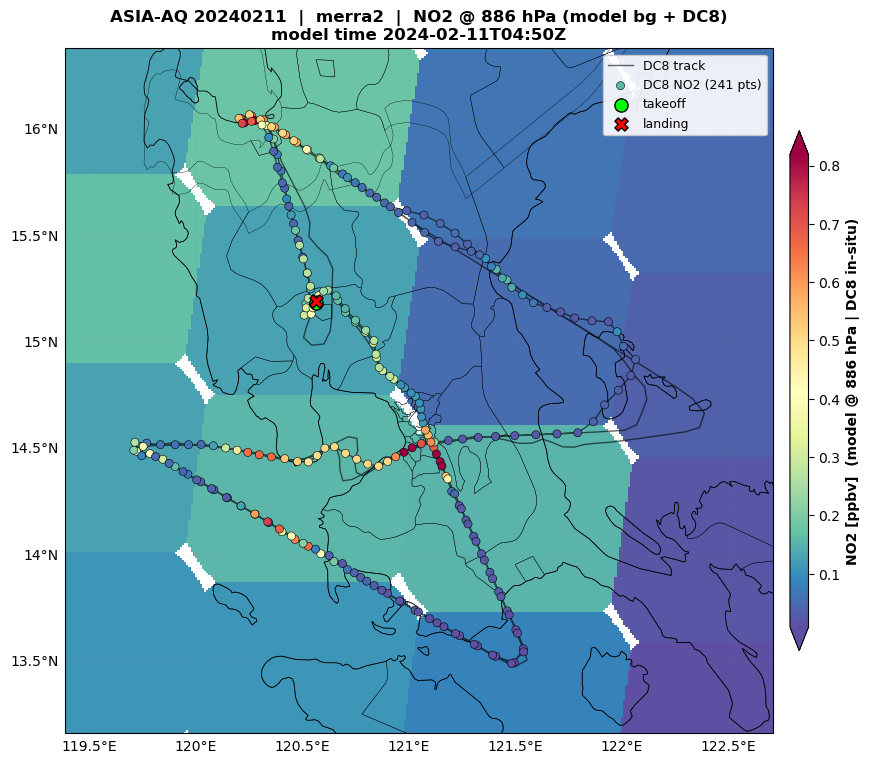

  merra2: NO2@886hPa, scale 0.0087-0.82 ppbv -> ./asiaaq_20240211_merra2_NO2_flightlevel_overlay.png


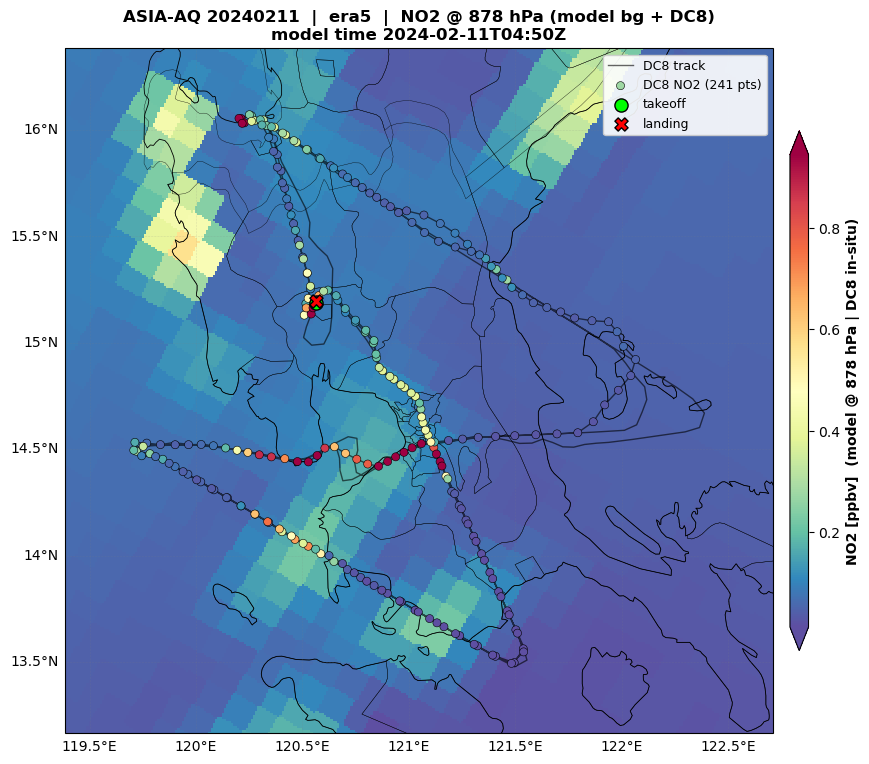

  era5: NO2@878hPa, scale 0.014-0.94 ppbv -> ./asiaaq_20240211_era5_NO2_flightlevel_overlay.png


In [88]:
# run aircraft spoverlay 

date = "20240211"
dc8 = {"era5": "/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/louisa_asiaaq_cs/asiaaq_cs_06082026/output/pair/asiaaq_20240211_dc8_cam-chem-se-era5.nc4",
       "merra2":   "/glade/u/home/lcthompson/mm/MELODIES-MONET/docs/examples/ungridded_support/unstructured_grid_read_uxarray/louisa_asiaaq_cs/asiaaq_cs_06082026/output/pair/asiaaq_20240211_dc8_cam-chem-se-merra2.nc4"}


for run in ("merra2", "era5"):
    model_flight_overlay(date, run, dc8[run], species="NO2", outdir=".", dot_source="model")